In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
# 1. Define the Lorenz System
def lorenz(t, state, sigma, rho, beta):
    """
    Computes the derivatives of the Lorenz system.
    
    Args:
        t (float): Current time (not explicitly used, but required by solvers).
        state (tuple or list): Current state (x, y, z).
        sigma, rho, beta (float): Parameters of the Lorenz system.
        
    Returns:
        list: Derivatives [dx/dt, dy/dt, dz/dt].
    """
    x, y, z = state
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    return [dx_dt, dy_dt, dz_dt]

# 2. Set Parameters and Integrate ODEs
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
params = (sigma, rho, beta)

# Initial condition
initial_state = [1.0, 1.0, 1.0] 

# Time span for integration
t_start = 0
t_end = 100
dt = 0.01 # Time step for evaluation
t_span = [t_start, t_end]
t_eval = np.arange(t_start, t_end, dt)

# --- Solve the ODE ---
# solve_ivp is generally recommended over odeint
sol = solve_ivp(lorenz, t_span, initial_state, args=params, 
                dense_output=True, t_eval=t_eval, method='RK45')

# --- Discard initial transient phase ---
# Allow the system to settle onto the attractor
transient_points = 1000 # Number of initial points to discard
if len(sol.t) > transient_points:
    t = sol.t[transient_points:]
    x, y, z = sol.y[:, transient_points:]
else:
    print("Warning: Integration time might be too short to discard transient.")
    t = sol.t
    x, y, z = sol.y
    
print(f"Generated {len(t)} points after discarding transient.")

# 3. Extract x(t) coordinate
x_t = x # Our observable time series

# 4. Time-Delay Embedding Function
def time_delay_embedding(series, dimension, lag):
    """
    Performs time-delay embedding on a time series.
    
    Args:
        series (np.array): The input time series (1D array).
        dimension (int): The embedding dimension (d).
        lag (int): The time delay/lag (tau) in terms of array indices.
        
    Returns:
        np.array: The embedded data, shape (N - (dimension-1)*lag, dimension).
                  Returns None if the series is too short.
    """
    n = len(series)
    max_required_index = (dimension - 1) * lag
    
    if n <= max_required_index:
        print(f"Error: Series length ({n}) is too short for dimension {dimension} and lag {lag}.")
        return None
        
    embedded_data = np.zeros((n - max_required_index, dimension))
    
    for i in range(dimension):
        embedded_data[:, i] = series[i * lag : i * lag + embedded_data.shape[0]]
        
    return embedded_data

# 5. Choose Embedding Parameters (d and tau)
embedding_dimension = 3 # Standard choice for visualizing Lorenz
# --- Choosing the lag (tau) ---
# A common heuristic is to use the first minimum of the mutual information
# or the first zero crossing/decay to 1/e of the autocorrelation function.
# Let's calculate autocorrelation for a suggestion.

def autocorrelation(series, max_lag):
    """Calculate autocorrelation using numpy correlate."""
    series_mean = np.mean(series)
    series_centered = series - series_mean
    var = np.var(series_centered)
    n = len(series_centered)
    
    # Use 'full' mode to get all possible lags
    corr = np.correlate(series_centered, series_centered, mode='full')
    
    # Normalize and take the second half (positive lags)
    autocorr = corr[n-1:] / (var * n) 
    return autocorr[:max_lag+1]

max_lag_autocorr = 100 # Check up to this lag
autocorr_x = autocorrelation(x_t, max_lag_autocorr)

# Find first time autocorrelation drops near zero or significantly
# This is heuristic - visual inspection is often helpful
first_zero_crossing = np.where(autocorr_x <= 0)[0]
first_significant_drop = np.where(autocorr_x <= 1/np.e)[0]

if len(first_zero_crossing) > 0:
    suggested_lag_zero = first_zero_crossing[0]
    print(f"Autocorrelation first crosses zero near lag: {suggested_lag_zero}")
elif len(first_significant_drop) > 0:
     suggested_lag_zero = first_significant_drop[0] # Use 1/e drop if no zero crossing
     print(f"Autocorrelation first drops below 1/e near lag: {suggested_lag_zero}")
else:
    suggested_lag_zero = 10 # Fallback value
    print(f"Could not find suitable lag from autocorrelation, using default: {suggested_lag_zero}")

# Let's choose a lag based on this (adjust if needed based on plots/heuristics)
time_lag = suggested_lag_zero 
# Common values used in literature for Lorenz with dt=0.01 are often around 10-15.
# Let's potentially cap it or manually set it if the suggestion seems off.
if not (5 < time_lag < 25): # Put some reasonable bounds based on experience
     print(f"Autocorrelation suggested lag {time_lag} seems unusual, setting manually to 12.")
     time_lag = 12 # A typical value often used

print(f"Using embedding dimension d = {embedding_dimension}, time lag tau = {time_lag} steps ({time_lag*dt:.2f} time units)")

# 6. Perform Embedding
embedded_x = time_delay_embedding(x_t, embedding_dimension, time_lag)


Generated 9000 points after discarding transient.
Autocorrelation first drops below 1/e near lag: 30
Autocorrelation suggested lag 30 seems unusual, setting manually to 12.
Using embedding dimension d = 3, time lag tau = 12 steps (0.12 time units)


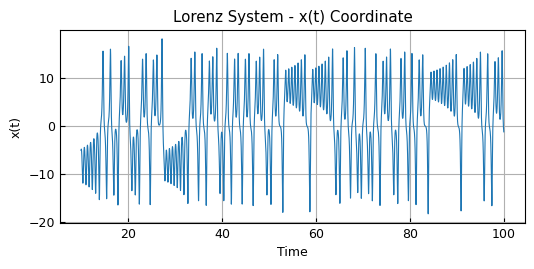

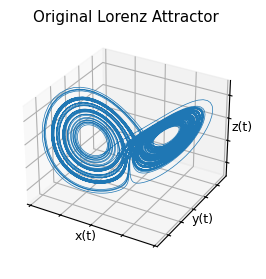

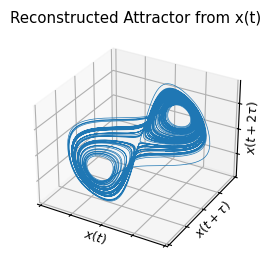

In [17]:
# 7. Plotting
#plt.style.use('seaborn-v0_8-darkgrid') # A nice plotting style

# Plot 1: Original x(t) time series
plt.figure(figsize=(6, 2.5))
plt.plot(t, x_t, lw=0.8)
plt.title('Lorenz System - x(t) Coordinate')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.grid(True)
plt.savefig('1D_Lorentzs.svg',transparent=True,bbox_inches='tight')

# Plot 2: Autocorrelation function
#plt.figure(figsize=(10, 4))
#plt.plot(np.arange(max_lag_autocorr + 1) * dt, autocorr_x, marker='.')
#plt.axhline(0, color='gray', linestyle='--', lw=1)
#plt.axhline(1/np.e, color='red', linestyle='--', lw=1, label='1/e level')
#plt.axvline(time_lag * dt, color='green', linestyle=':', lw=2, label=f'Chosen lag ({time_lag*dt:.2f})')
#plt.title('Autocorrelation of x(t)')
#plt.xlabel(f'Lag (Time Units, dt={dt})')
#plt.ylabel('Autocorrelation')
#plt.xlim(0, max_lag_autocorr * dt)
#plt.legend()
#plt.grid(True)


# Plot 3: Original Lorenz Attractor (3D)
fig1 = plt.figure(figsize=(4, 3))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(x, y, z, lw=0.5)
ax1.set_title("Original Lorenz Attractor")
ax1.set_xlabel("x(t)",labelpad=-15.)
ax1.set_ylabel("y(t)",labelpad=-15.)
ax1.set_zlabel("z(t)",labelpad=-15.)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_zticklabels([])
#fig1.savefig('3D_Lorentz.svg',transparent=True,bbox_inches='tight')

# Plot 4: Reconstructed Attractor using Time-Delay Embedding (3D)
if embedded_x is not None:
    fig2 = plt.figure(figsize=(4, 3))
    ax2 = fig2.add_subplot(111, projection='3d')
    # Access columns of the embedded data
    x_emb_0 = embedded_x[:, 0] # Corresponds to x(t)
    x_emb_1 = embedded_x[:, 1] # Corresponds to x(t + tau)
    x_emb_2 = embedded_x[:, 2] # Corresponds to x(t + 2*tau)
    ax2.plot(x_emb_0, x_emb_1, x_emb_2, lw=0.5)
    ax2.set_title(f"Reconstructed Attractor from x(t)")# (d={embedding_dimension}, tau={time_lag*dt:.2f})")
    ax2.set_xlabel(r"$x(t)$",labelpad=-15.)
    ax2.set_ylabel(r"$x(t + \tau)$",labelpad=-15.)
    ax2.set_zlabel(r"$x(t + 2\tau)$",labelpad=-15.)

    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_zticklabels([])

#fig2.savefig('reconstructed_Lorentz.svg',transparent=True,bbox_inches='tight')